            "source": [
                "'''",
                "UMAP Visualization Script for PBMC68k Dataset",
                "This script decodes the generated latent embedding into gene expression matrix ",
                "and creates UMAP visualizations comparing real vs generated cells",
                "'''"
            ]

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import sys
import warnings
warnings.filterwarnings('ignore')

# Add path to VAE module
sys.path.append('/home/suzuki/Projects/scDiffusion/VAE')
from VAE_model import VAE

# Set up scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

print("Environment set up successfully!")

Environment set up successfully!


## Load VAE Model

In [2]:
# Add VAE module to path
import sys
sys.path.append('/home/suzuki/Projects/scDiffusion')

def load_vae_model():
    """Load VAE model for PBMC68k dataset"""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    model_path = '/home/suzuki/Projects/scDiffusion/output/checkpoint/AE/pbmc68k/model_seed=0_step=9999.pt'
    
    try:
        from VAE.VAE_model import VAE
        autoencoder = VAE(
            num_genes=32738,  # PBMC68k dataset has 32738 genes
            device=device,
            seed=0,
            loss_ae="gauss",
            decoder_activation="linear",
            hidden_dim=128
        )
        checkpoint = torch.load(model_path, map_location=device)
        autoencoder.load_state_dict(checkpoint)
        autoencoder.to(device)
        autoencoder.eval()
        print(f"VAE model loaded successfully from {model_path}")
        return autoencoder
    except Exception as e:
        print(f"Error loading VAE model: {e}")
        return None

# Load the VAE model
autoencoder = load_vae_model()

VAE model loaded successfully from /home/suzuki/Projects/scDiffusion/output/checkpoint/AE/pbmc68k/model_seed=0_step=9999.pt


## Load Real PBMC68k Data

In [3]:
# Load PBMC68k dataset
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/data_preparation/pbmc68k.h5ad')

print(f"Original data shape: {adata.shape}")
print(f"Available obs columns: {list(adata.obs.columns)}")

# Find the correct cell type column
cell_type_col = None
for col in ['celltype', 'cell_type', 'Celltype', 'Cell_type']: #clusters→celltypeに変更済み
    if col in adata.obs.columns:
        cell_type_col = col
        break

if cell_type_col:
    print(f"Using cell type column: {cell_type_col}")
    print(f"Cell types: {list(adata.obs[cell_type_col].unique())}")
    celltype = adata.obs[cell_type_col]
else:
    print("Warning: No cell type column found")
    celltype = None

"""
★★★★★★★★★★★★★★★★★★★★★★★★★★
追加の処理
★★★★★★★★★★★★★★★★★★★★★★★★★★

pancreasのデータではnormalize_totalとlog1pが実行されていない。
一方で、VAE_train, cell_train, classifier_trainでは
normalize_totalとlog1pが実行されている。
そのため、ここではnormalize_totalとlog1pを実行する。

処理内容はguided_diffusion/cell_datasets_loader.pyのload_data関数を参照。
"""
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Get gene expression data (already log-normalized)
if hasattr(adata.X, 'toarray'):
    cell_data = adata.X.toarray()
else:
    cell_data = adata.X

print(f"Cell data shape: {cell_data.shape}")
print(f"Gene names: {len(adata.var_names)} genes")

# Store gene names for later use
gene_names = adata.var_names.tolist()

Original data shape: (68579, 32738)
Available obs columns: ['TSNE.1', 'TSNE.2', 'celltype']
Using cell type column: celltype
Cell types: ['CD8+ Cytotoxic T', 'CD8+/CD45RA+ Naive Cytotoxic', 'CD4+/CD45RO+ Memory', 'CD19+ B', 'CD4+/CD25 T Reg', 'CD56+ NK', 'CD4+ T Helper2', 'CD4+/CD45RA+/CD25- Naive T', 'CD34+', 'Dendritic', 'CD14+ Monocyte']
normalizing counts per cell
    finished (0:00:00)
    finished (0:00:00)
Cell data shape: (68579, 32738)
Gene names: 32738 genes
Cell data shape: (68579, 32738)
Gene names: 32738 genes


## Load and Decode Unconditional Generated Data

In [4]:
# Load unconditional generated samples
unconditional_path = '/home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k/classifier_guided/unconditional_samples.npz'

print("Loading unconditional generated samples...")
cell_gen = None

try:
    npzfile = np.load(unconditional_path, allow_pickle=True)
    print(f"Available keys in file: {list(npzfile.keys())}")

    # Use the correct key
    if 'cell_gen' in npzfile.keys():
        cell_gen_latent = npzfile['cell_gen'][:3000]  # Use 3000 samples
        print("Using 'cell_gen' key")
    elif 'arr_0' in npzfile.keys():
        cell_gen_latent = npzfile['arr_0'][:3000]
        print("Using 'arr_0' key")
    else:
        key = list(npzfile.keys())[0]
        cell_gen_latent = npzfile[key][:3000]
        print(f"Using key: {key}")

    print(f"Loaded latent samples shape: {cell_gen_latent.shape}")

    # Decode to gene expression space
    if autoencoder is not None:
        with torch.no_grad():
            device = next(autoencoder.parameters()).device
            cell_gen_tensor = torch.tensor(cell_gen_latent, dtype=torch.float32).to(device)
            cell_gen = autoencoder(cell_gen_tensor, return_decoded=True).cpu().detach().numpy()

        print(f"Decoded unconditional samples shape: {cell_gen.shape}")
    else:
        print("Failed to load VAE model")
        
except FileNotFoundError:
    print(f"Unconditional samples file not found at: {unconditional_path}")
except Exception as e:
    print(f"Error loading unconditional samples: {e}")

Loading unconditional generated samples...
Unconditional samples file not found at: /home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k/classifier_guided/unconditional_samples.npz


## Load and Decode Conditional Generated Data

In [5]:
# Load conditional generated samples for PBMC68k
conditional_base_path = '/home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k/conditional/type_{}_{}.npz'
cell_types = ['CD8+ Cytotoxic T', 'CD8+/CD45RA+ Naive Cytotoxic', 'CD4+/CD45RO+ Memory', 'CD19+ B', 'CD4+/CD25 T Reg', 'CD56+ NK', 'CD4+ T Helper2', 'CD4+/CD45RA+/CD25- Naive T', 'CD34+', 'Dendritic', 'CD14+ Monocyte']

print("Loading conditional generated samples...")
conditional_samples = []
gen_class = []
cell_gen_conditional = None

for i in range(11):
    cond_path = conditional_base_path.format(i, i)
    try:
        npzfile = np.load(cond_path, allow_pickle=True)
        print(f"Type {i} ({cell_types[i]}) - Available keys: {list(npzfile.keys())}")
        
        # Use the correct key
        if 'cell_gen' in npzfile.keys():
            cond_samples = npzfile['cell_gen'][:500]  # 500 samples per type
        elif 'arr_0' in npzfile.keys():
            cond_samples = npzfile['arr_0'][:500]
        else:
            key = list(npzfile.keys())[0]
            cond_samples = npzfile[key][:500]
        
        conditional_samples.append(cond_samples)
        gen_class.extend([f'gen {cell_types[i]}'] * len(cond_samples))
        print(f"Loaded {len(cond_samples)} samples for {cell_types[i]}")
        
    except FileNotFoundError:
        print(f"Warning: File not found for type {i} ({cell_types[i]})")
        continue

if conditional_samples and autoencoder is not None:
    # Combine all conditional samples
    all_conditional_latent = np.vstack(conditional_samples)
    print(f"Total conditional latent samples: {all_conditional_latent.shape}")
    
    # Decode conditional samples
    with torch.no_grad():
        device = next(autoencoder.parameters()).device
        cond_tensor = torch.tensor(all_conditional_latent, dtype=torch.float32).to(device)
        cell_gen_conditional = autoencoder(cond_tensor, return_decoded=True).cpu().detach().numpy()
    
    print(f"Decoded conditional samples shape: {cell_gen_conditional.shape}")
else:
    print("No conditional samples found or VAE model not available")
    cell_gen_conditional = None
    gen_class = []

Loading conditional generated samples...
Type 0 (CD8+ Cytotoxic T) - Available keys: ['cell_gen']
Loaded 500 samples for CD8+ Cytotoxic T
Type 1 (CD8+/CD45RA+ Naive Cytotoxic) - Available keys: ['cell_gen']
Loaded 500 samples for CD8+/CD45RA+ Naive Cytotoxic
Type 2 (CD4+/CD45RO+ Memory) - Available keys: ['cell_gen']
Loaded 500 samples for CD4+/CD45RO+ Memory
Type 3 (CD19+ B) - Available keys: ['cell_gen']
Loaded 500 samples for CD19+ B
Type 4 (CD4+/CD25 T Reg) - Available keys: ['cell_gen']
Loaded 500 samples for CD4+/CD25 T Reg
Type 5 (CD56+ NK) - Available keys: ['cell_gen']
Loaded 500 samples for CD56+ NK
Type 4 (CD4+/CD25 T Reg) - Available keys: ['cell_gen']
Loaded 500 samples for CD4+/CD25 T Reg
Type 5 (CD56+ NK) - Available keys: ['cell_gen']
Loaded 500 samples for CD56+ NK


Type 6 (CD4+ T Helper2) - Available keys: ['cell_gen']
Loaded 500 samples for CD4+ T Helper2
Type 7 (CD4+/CD45RA+/CD25- Naive T) - Available keys: ['cell_gen']
Loaded 500 samples for CD4+/CD45RA+/CD25- Naive T
Type 8 (CD34+) - Available keys: ['cell_gen']
Loaded 500 samples for CD34+
Type 9 (Dendritic) - Available keys: ['cell_gen']
Loaded 500 samples for Dendritic
Type 10 (CD14+ Monocyte) - Available keys: ['cell_gen']
Loaded 500 samples for CD14+ Monocyte
Total conditional latent samples: (5500, 128)
Loaded 500 samples for Dendritic
Type 10 (CD14+ Monocyte) - Available keys: ['cell_gen']
Loaded 500 samples for CD14+ Monocyte
Total conditional latent samples: (5500, 128)
Decoded conditional samples shape: (5500, 32738)
Decoded conditional samples shape: (5500, 32738)


## Gene Expression Correlation Analysis

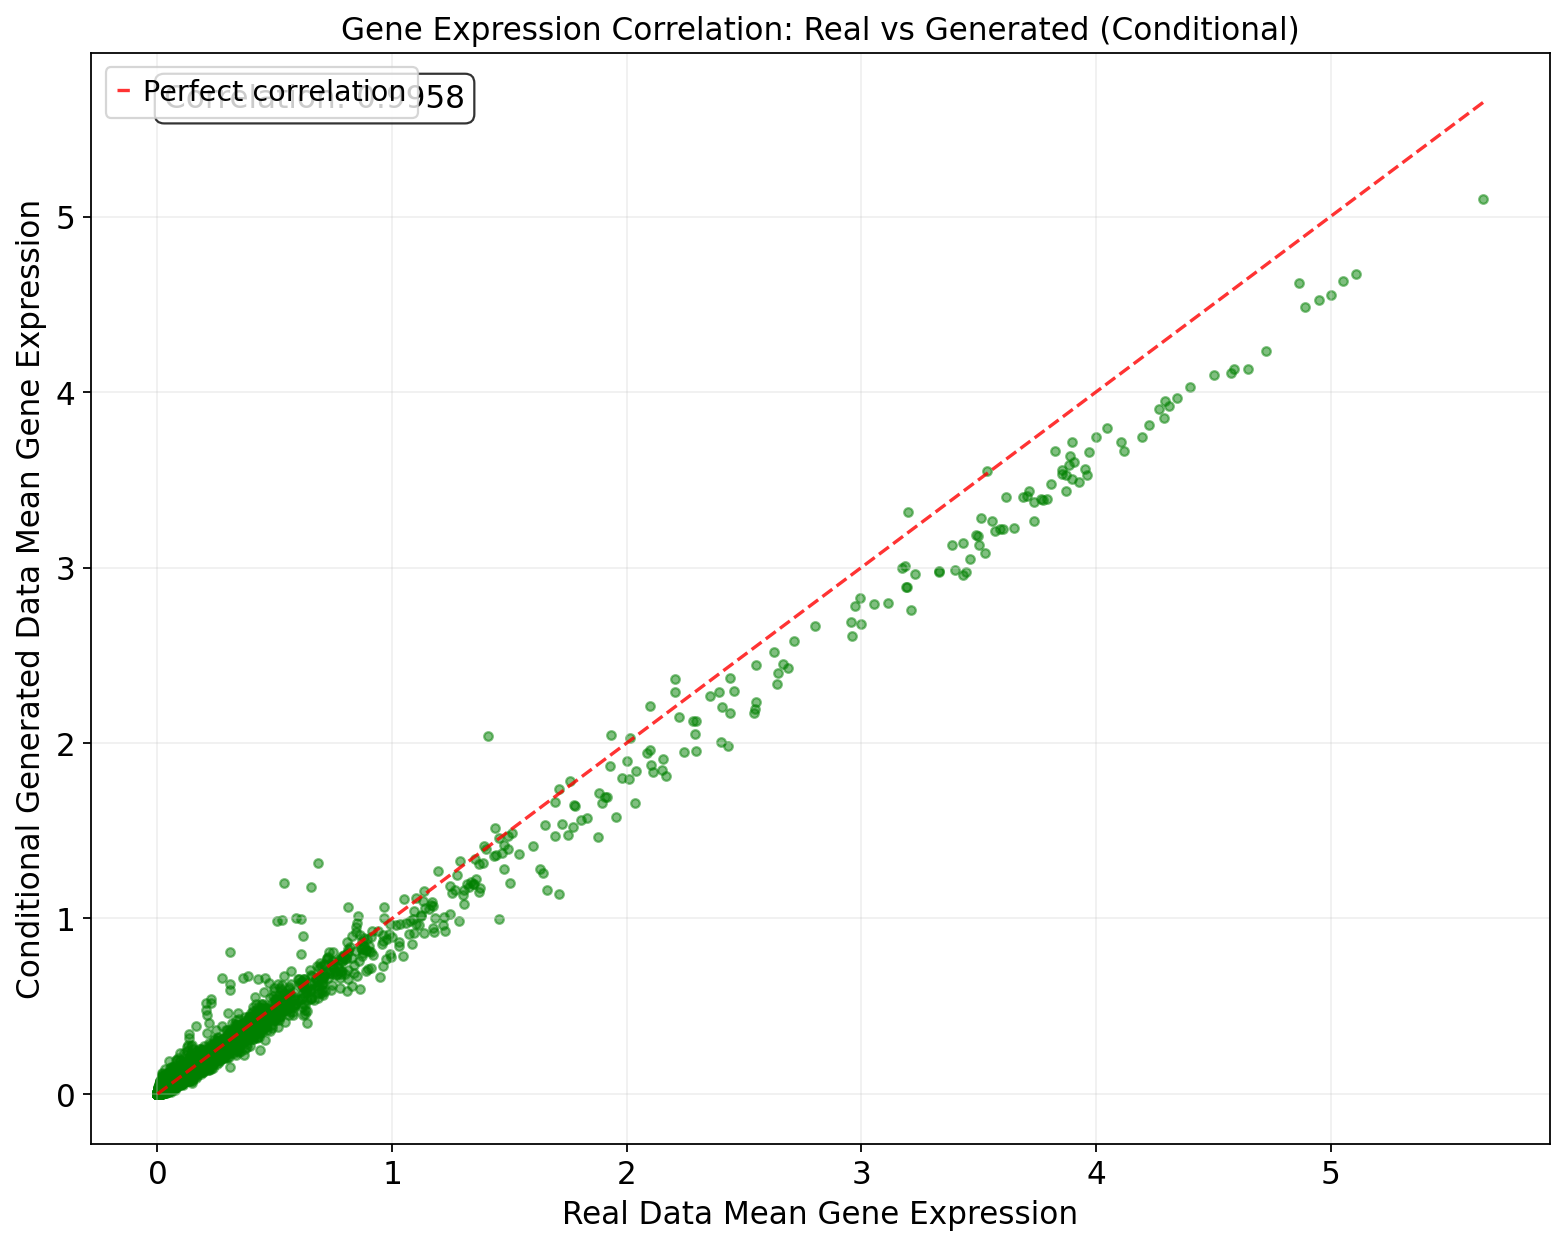

Conditional generation correlation: 0.9958


In [6]:
# Analyze gene expression correlation between real and generated data
if cell_gen is not None:
    # Calculate mean expression per gene
    real_gene_means = cell_data.mean(axis=0)
    gen_gene_means = cell_gen.mean(axis=0)
    
    # Plot correlation
    plt.figure(figsize=(10, 8))
    plt.scatter(real_gene_means, gen_gene_means, alpha=0.5, s=15)
    plt.xlabel('Real Data Mean Gene Expression')
    plt.ylabel('Generated Data Mean Gene Expression')
    plt.title('Gene Expression Correlation: Real vs Generated (Unconditional)')
    
    # Add diagonal line
    min_val = min(real_gene_means.min(), gen_gene_means.min())
    max_val = max(real_gene_means.max(), gen_gene_means.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect correlation')
    
    # Calculate correlation
    corr_coef = np.corrcoef(real_gene_means, gen_gene_means)[0, 1]
    plt.text(0.05, 0.95, f'Correlation: {corr_coef:.4f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Unconditional generation correlation: {corr_coef:.4f}")

# Conditional correlation if available
if cell_gen_conditional is not None:
    plt.figure(figsize=(10, 8))
    real_gene_means = cell_data.mean(axis=0)
    cond_gene_means = cell_gen_conditional.mean(axis=0)
    plt.scatter(real_gene_means, cond_gene_means, alpha=0.5, s=15, color='green')
    plt.xlabel('Real Data Mean Gene Expression')
    plt.ylabel('Conditional Generated Data Mean Gene Expression')
    plt.title('Gene Expression Correlation: Real vs Generated (Conditional)')
    
    # Add diagonal line
    min_val = min(real_gene_means.min(), cond_gene_means.min())
    max_val = max(real_gene_means.max(), cond_gene_means.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect correlation')
    
    # Calculate correlation
    corr_coef_cond = np.corrcoef(real_gene_means, cond_gene_means)[0, 1]
    plt.text(0.05, 0.95, f'Correlation: {corr_coef_cond:.4f}', transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Conditional generation correlation: {corr_coef_cond:.4f}")

## Prepare Combined Data for UMAP

In [7]:
# Prepare data for UMAP visualization
print("Preparing data for UMAP...")

# Choose which generated data to use (prefer conditional if available)
if cell_gen_conditional is not None:
    cell_gen_final = cell_gen_conditional
    gen_class_final = gen_class
    print("Using conditional generated data for UMAP")
elif cell_gen is not None:
    cell_gen_final = cell_gen
    gen_class_final = [f"gen_Cell" for i in range(cell_gen.shape[0])]
    print("Using unconditional generated data for UMAP")
else:
    print("No generated data available!")
    cell_gen_final = None

if cell_gen_final is not None:
    # Combine real and generated data
    all_data = np.concatenate((cell_data, cell_gen_final), axis=0)
    adata_combined = ad.AnnData(all_data, dtype=np.float32)
    
    print(f"Combined data shape: {adata_combined.shape}")
    
    # Create cell labels (real vs generated)
    cell_names = [f"Real_Cell" for i in range(cell_data.shape[0])] + \
                 [f"Generated_Cell" for i in range(cell_gen_final.shape[0])]
    adata_combined.obs['cell_origin'] = cell_names
    
    # Add cell type information if available
    if celltype is not None and cell_gen_conditional is not None:
        # For real cells, use actual cell types
        real_cell_types = celltype.values if hasattr(celltype, 'values') else celltype
        # For generated cells, use generated cell types
        all_cell_types = list(real_cell_types) + gen_class_final
        adata_combined.obs['celltype'] = all_cell_types
        print(f"Added cell type information: {len(set(all_cell_types))} unique types")
    else:
        print("Cell type information not available or incomplete")
    
    print("Data preparation completed!")
else:
    print("Cannot create UMAP without generated data")

Preparing data for UMAP...
Using conditional generated data for UMAP


Combined data shape: (74079, 32738)
Added cell type information: 22 unique types
Data preparation completed!


## UMAP Preprocessing and Computation

In [8]:
# Check for infinite values and data quality before UMAP preprocessing
if 'adata_combined' in locals():
    print("Checking and fixing data quality...")
    
    # Ensure we have a proper numpy array
    if not isinstance(adata_combined.X, np.ndarray):
        print("Converting to numpy array...")
        adata_combined.X = np.array(adata_combined.X, dtype=np.float32)
    
    # Check for infinite values
    n_inf = np.isinf(adata_combined.X).sum()
    n_nan = np.isnan(adata_combined.X).sum()
    
    print(f"Initial infinite values: {n_inf}")
    print(f"Initial NaN values: {n_nan}")
    
    # Fix infinite and NaN values
    if n_inf > 0 or n_nan > 0:
        print("Fixing infinite and NaN values...")
        
        # Replace infinite values with very large/small finite values
        adata_combined.X[np.isposinf(adata_combined.X)] = np.finfo(np.float32).max
        adata_combined.X[np.isneginf(adata_combined.X)] = np.finfo(np.float32).min
        
        # Replace NaN values with 0
        adata_combined.X[np.isnan(adata_combined.X)] = 0.0
        
        # Check again
        n_inf_after = np.isinf(adata_combined.X).sum()
        n_nan_after = np.isnan(adata_combined.X).sum()
        
        print(f"After fixing - infinite values: {n_inf_after}")
        print(f"After fixing - NaN values: {n_nan_after}")
    
    # Clip extremely large values to reasonable range
    data_max = np.max(adata_combined.X)
    data_min = np.min(adata_combined.X)
    print(f"Data range before clipping: [{data_min:.4f}, {data_max:.4f}]")
    
    # Clip to reasonable range (percentile-based)
    p99 = np.percentile(adata_combined.X, 99.9)
    p01 = np.percentile(adata_combined.X, 0.1)
    print(f"99.9th percentile: {p99:.4f}, 0.1th percentile: {p01:.4f}")
    
    adata_combined.X = np.clip(adata_combined.X, p01, p99)
    
    # Final check
    data_max_final = np.max(adata_combined.X)
    data_min_final = np.min(adata_combined.X)
    print(f"Data range after clipping: [{data_min_final:.4f}, {data_max_final:.4f}]")
    
    # Ensure no infinite or NaN values remain
    assert not np.any(np.isinf(adata_combined.X)), "Infinite values still present!"
    assert not np.any(np.isnan(adata_combined.X)), "NaN values still present!"
    
    print(f"Final data shape: {adata_combined.shape}")
    print("Data quality check and fixing completed!")
else:
    print("No combined data available for quality check")

Checking and fixing data quality...
Initial infinite values: 0
Initial NaN values: 0
Initial infinite values: 0
Initial NaN values: 0
Data range before clipping: [0.0000, 7.5259]
Data range before clipping: [0.0000, 7.5259]
99.9th percentile: 4.1214, 0.1th percentile: 0.0000
99.9th percentile: 4.1214, 0.1th percentile: 0.0000
Data range after clipping: [0.0000, 4.1214]
Data range after clipping: [0.0000, 4.1214]
Final data shape: (74079, 32738)
Data quality check and fixing completed!
Final data shape: (74079, 32738)
Data quality check and fixing completed!


In [9]:
if 'adata_combined' in locals():
    print("Preprocessing data for UMAP...")
    
    # Check data before preprocessing
    print(f"Data shape before preprocessing: {adata_combined.shape}")
    print(f"Data type: {type(adata_combined.X)}")
    print(f"Data range: [{adata_combined.X.min():.4f}, {adata_combined.X.max():.4f}]")
    
    try:
        # Ensure proper data type
        adata_combined.X = adata_combined.X.astype(np.float32)
        
        # Add small epsilon to avoid zero variance issues
        # adata_combined.X = adata_combined.X + 1e-10
        
        # Use manual gene selection approach to avoid highly_variable_genes issues
        print("Using manual gene selection (top 2000 most variable genes)...")
        
        # Calculate gene variances manually
        gene_variances = np.var(adata_combined.X, axis=0)
        
        # The data is already log-normalized, so we proceed with feature selection
        print("Running highly variable genes detection...")
        sc.pp.highly_variable_genes(adata_combined, min_mean=0.0125, max_mean=3, min_disp=0.5)
        print(f"Found {sum(adata_combined.var.highly_variable)} highly variable genes")
        
        # Store raw data and filter
        adata_combined.raw = adata_combined
        adata_combined = adata_combined[:, adata_combined.var.highly_variable]
        
        print(f"Data after filtering: {adata_combined.shape}")
        
        # Scale data
        print("Scaling data...")
        sc.pp.scale(adata_combined, max_value=10)
        
        # PCA
        print("Running PCA...")
        sc.tl.pca(adata_combined, svd_solver='arpack', n_comps=50)
        print("PCA completed!")
        
        # Neighbors and UMAP
        print("Computing neighbors...")
        sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
        
        print("Computing UMAP...")
        sc.tl.umap(adata_combined, min_dist=0.3, spread=1.0)
        
        print("UMAP computation completed successfully!")
        
        # Verify UMAP results
        print(f"UMAP coordinates shape: {adata_combined.obsm['X_umap'].shape}")
        print("UMAP preprocessing pipeline completed!")
        
    except Exception as e:
        print(f"Error during preprocessing: {e}")
        print(f"Error type: {type(e)}")
        
        # Try alternative approach with more conservative parameters
        print("\nTrying alternative approach...")
        try:
            # Ensure proper numpy array
            adata_combined.X = np.array(adata_combined.X, dtype=np.float32)
            
            # Apply a small epsilon to avoid issues
            adata_combined.X = adata_combined.X + 1e-8
            
            print("Trying highly variable genes with alternative parameters...")
            sc.pp.highly_variable_genes(adata_combined, min_mean=0.1, max_mean=5, min_disp=0.3, n_top_genes=2000)
            print(f"Found {sum(adata_combined.var.highly_variable)} highly variable genes (alternative method)")
            
            # Continue with rest of preprocessing
            adata_combined.raw = adata_combined
            adata_combined = adata_combined[:, adata_combined.var.highly_variable]
            
            print(f"Data after filtering: {adata_combined.shape}")
            
            sc.pp.scale(adata_combined, max_value=10)
            sc.tl.pca(adata_combined, svd_solver='arpack')
            sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
            sc.tl.umap(adata_combined)
            
            print("UMAP computation completed with alternative method!")
            
        except Exception as e2:
            print(f"Alternative approach also failed: {e2}")
            print("Will proceed with manual gene selection...")

Preprocessing data for UMAP...
Data shape before preprocessing: (74079, 32738)
Data type: <class 'numpy.ndarray'>
Data range: [0.0000, 4.1214]
Data range: [0.0000, 4.1214]
Using manual gene selection (top 2000 most variable genes)...
Using manual gene selection (top 2000 most variable genes)...
Running highly variable genes detection...
extracting highly variable genes
Running highly variable genes detection...
extracting highly variable genes
    finished (0:00:07)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
    finished (0:00:07)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Found 7974 highly variable genes
Found 7974 highly variable genes
Data after filtering: (74079, 7974)
Scaling data...
Data a

In [10]:
# # Manual highly variable gene selection as fallback
# if 'adata_combined' in locals():
#     print("\nUsing manual highly variable gene selection...")
    
#     try:
#         # Calculate gene statistics manually
#         print("Calculating gene statistics...")
        
#         # Calculate mean and variance for each gene
#         gene_means = np.mean(adata_combined.X, axis=0)
#         gene_vars = np.var(adata_combined.X, axis=0)
        
#         # Avoid division by zero and log of zero
#         gene_means_safe = np.maximum(gene_means, 1e-8)
#         gene_vars_safe = np.maximum(gene_vars, 1e-8)
        
#         # Calculate coefficient of variation (CV)
#         gene_cv = np.sqrt(gene_vars_safe) / gene_means_safe
        
#         # Select top variable genes based on CV
#         n_top_genes = 2000
#         top_gene_indices = np.argsort(gene_cv)[-n_top_genes:]
        
#         # Create highly variable mask
#         highly_variable_mask = np.zeros(adata_combined.shape[1], dtype=bool)
#         highly_variable_mask[top_gene_indices] = True
        
#         # Add to adata object
#         adata_combined.var['highly_variable'] = highly_variable_mask
#         adata_combined.var['means'] = gene_means
#         adata_combined.var['dispersions'] = gene_vars
        
#         print(f"Selected {n_top_genes} highly variable genes manually")
        
#         # Store raw data and filter
#         adata_combined.raw = adata_combined
#         adata_combined = adata_combined[:, adata_combined.var.highly_variable]
        
#         print(f"Data after filtering: {adata_combined.shape}")
        
#         # Scale data
#         print("Scaling data...")
#         sc.pp.scale(adata_combined, max_value=10)
        
#         # PCA
#         print("Running PCA...")
#         sc.tl.pca(adata_combined, svd_solver='arpack')
#         print("PCA completed!")
        
#         # Neighbors and UMAP
#         print("Computing neighbors...")
#         sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
        
#         print("Computing UMAP...")
#         sc.tl.umap(adata_combined)
        
#         print("UMAP computation completed with manual gene selection!")
        
#     except Exception as e:
#         print(f"Manual gene selection also failed: {e}")
#         print("This might indicate a deeper issue with the data preparation")
        
#         # Let's try a very simple approach - just use all genes
#         print("\nTrying with all genes (no filtering)...")
#         try:
#             # Clone the original data
#             adata_simple = adata_combined.copy()
            
#             # Just scale and run PCA/UMAP without gene filtering
#             sc.pp.scale(adata_simple, max_value=10)
#             sc.tl.pca(adata_simple, svd_solver='arpack', n_comps=50)
#             sc.pp.neighbors(adata_simple, n_neighbors=15, n_pcs=40)
#             sc.tl.umap(adata_simple)
            
#             # Replace the original with the working version
#             adata_combined = adata_simple
#             print("UMAP completed with all genes (no filtering)!")
            
#         except Exception as e3:
#             print(f"Even simple approach failed: {e3}")
#             print("There may be a fundamental issue with the data or environment")

## UMAP Visualization: Real vs Generated

Creating UMAP visualizations...


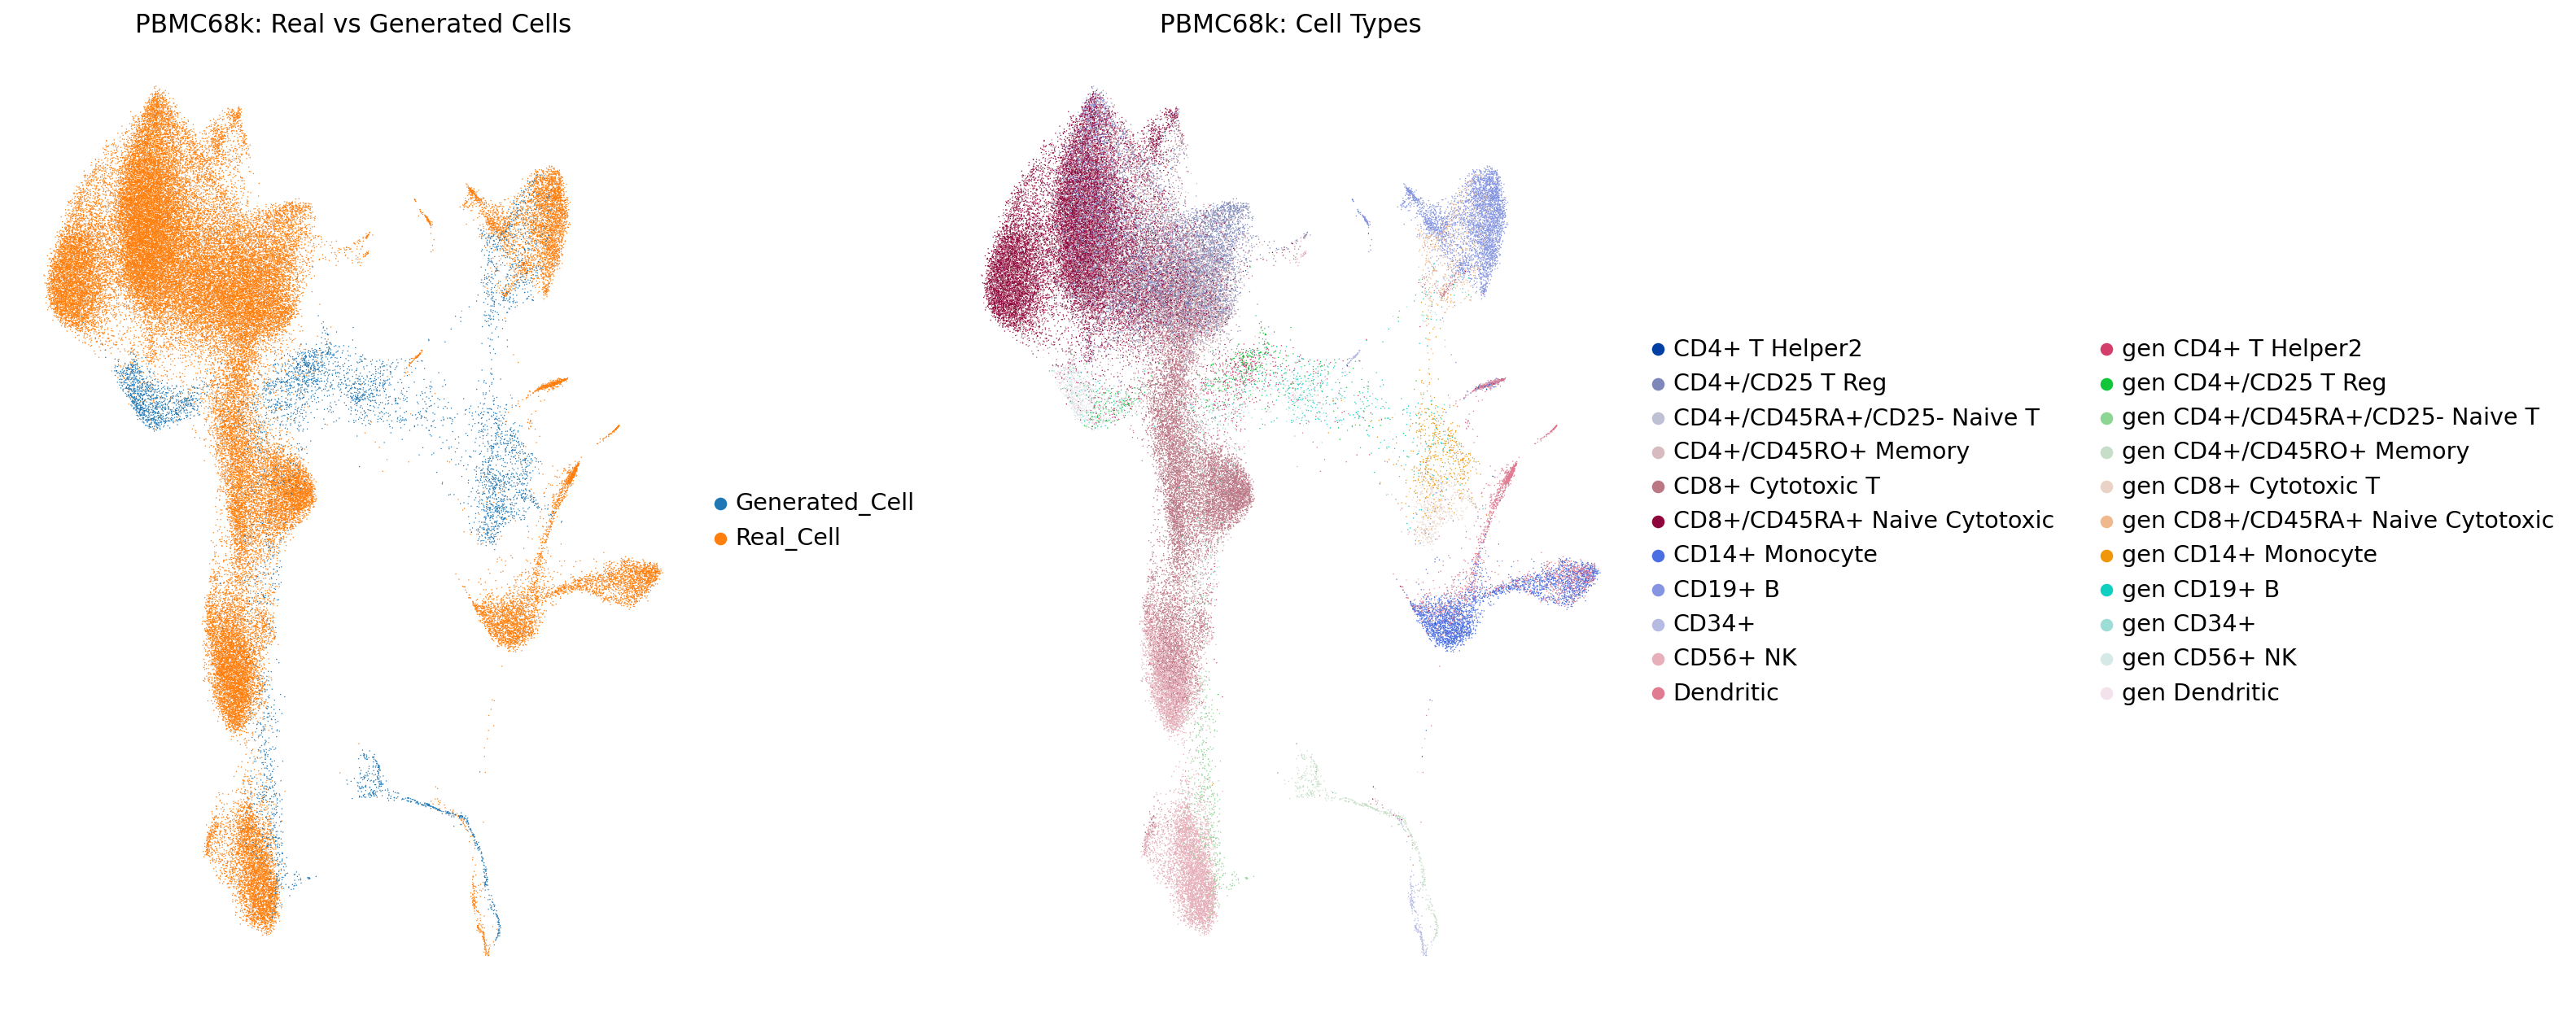

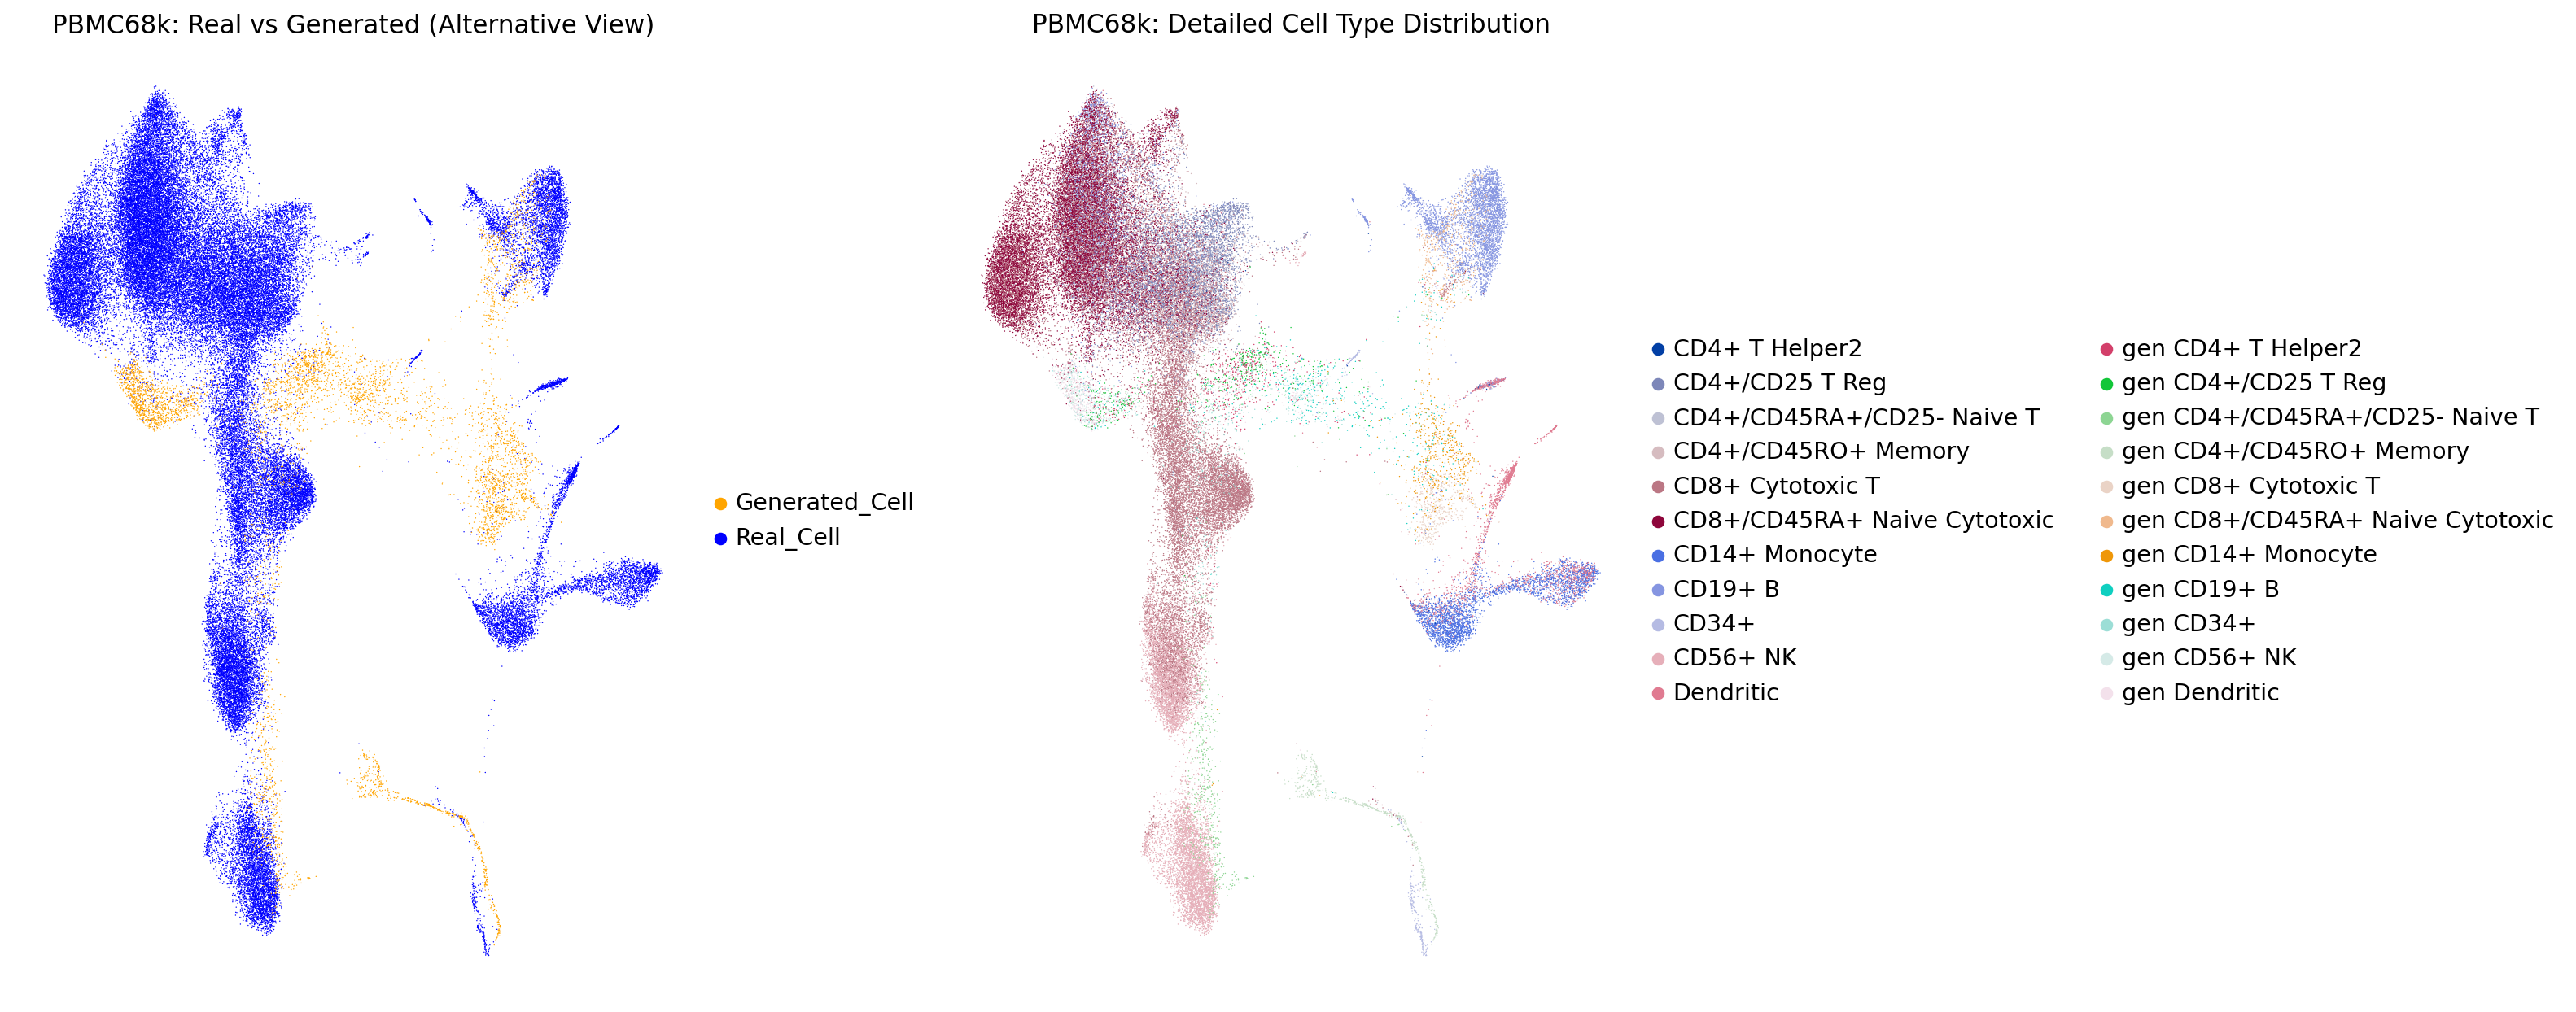

UMAP visualization completed!


In [11]:
if 'adata_combined' in locals() and 'X_umap' in adata_combined.obsm:
    print("Creating UMAP visualizations...")
    
    # Create UMAP plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Real vs Generated
    sc.pl.umap(adata_combined, 
               color='cell_origin', 
               ax=axes[0], 
               title='PBMC68k: Real vs Generated Cells', 
               frameon=False, 
               show=False)
    
    # Plot 2: Cell Types
    sc.pl.umap(adata_combined, 
               color='celltype', 
               ax=axes[1], 
               title='PBMC68k: Cell Types', 
               frameon=False, 
               show=False)
    
    plt.tight_layout()
    plt.show()
    
    # Alternative view with different color scheme
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    sc.pl.umap(adata_combined, 
               color='cell_origin', 
               palette=['orange', 'blue'], 
               ax=axes[0], 
               title='PBMC68k: Real vs Generated (Alternative View)', 
               frameon=False, 
               show=False)
    
    sc.pl.umap(adata_combined, 
               color='celltype', 
               ax=axes[1], 
               title='PBMC68k: Detailed Cell Type Distribution', 
               frameon=False, 
               show=False)
    
    plt.tight_layout()
    plt.show()
    
    print("UMAP visualization completed!")
else:
    print("UMAP results not available. Please run preprocessing first.")

## Individual Cell Type Comparisons

Creating individual cell type comparisons...


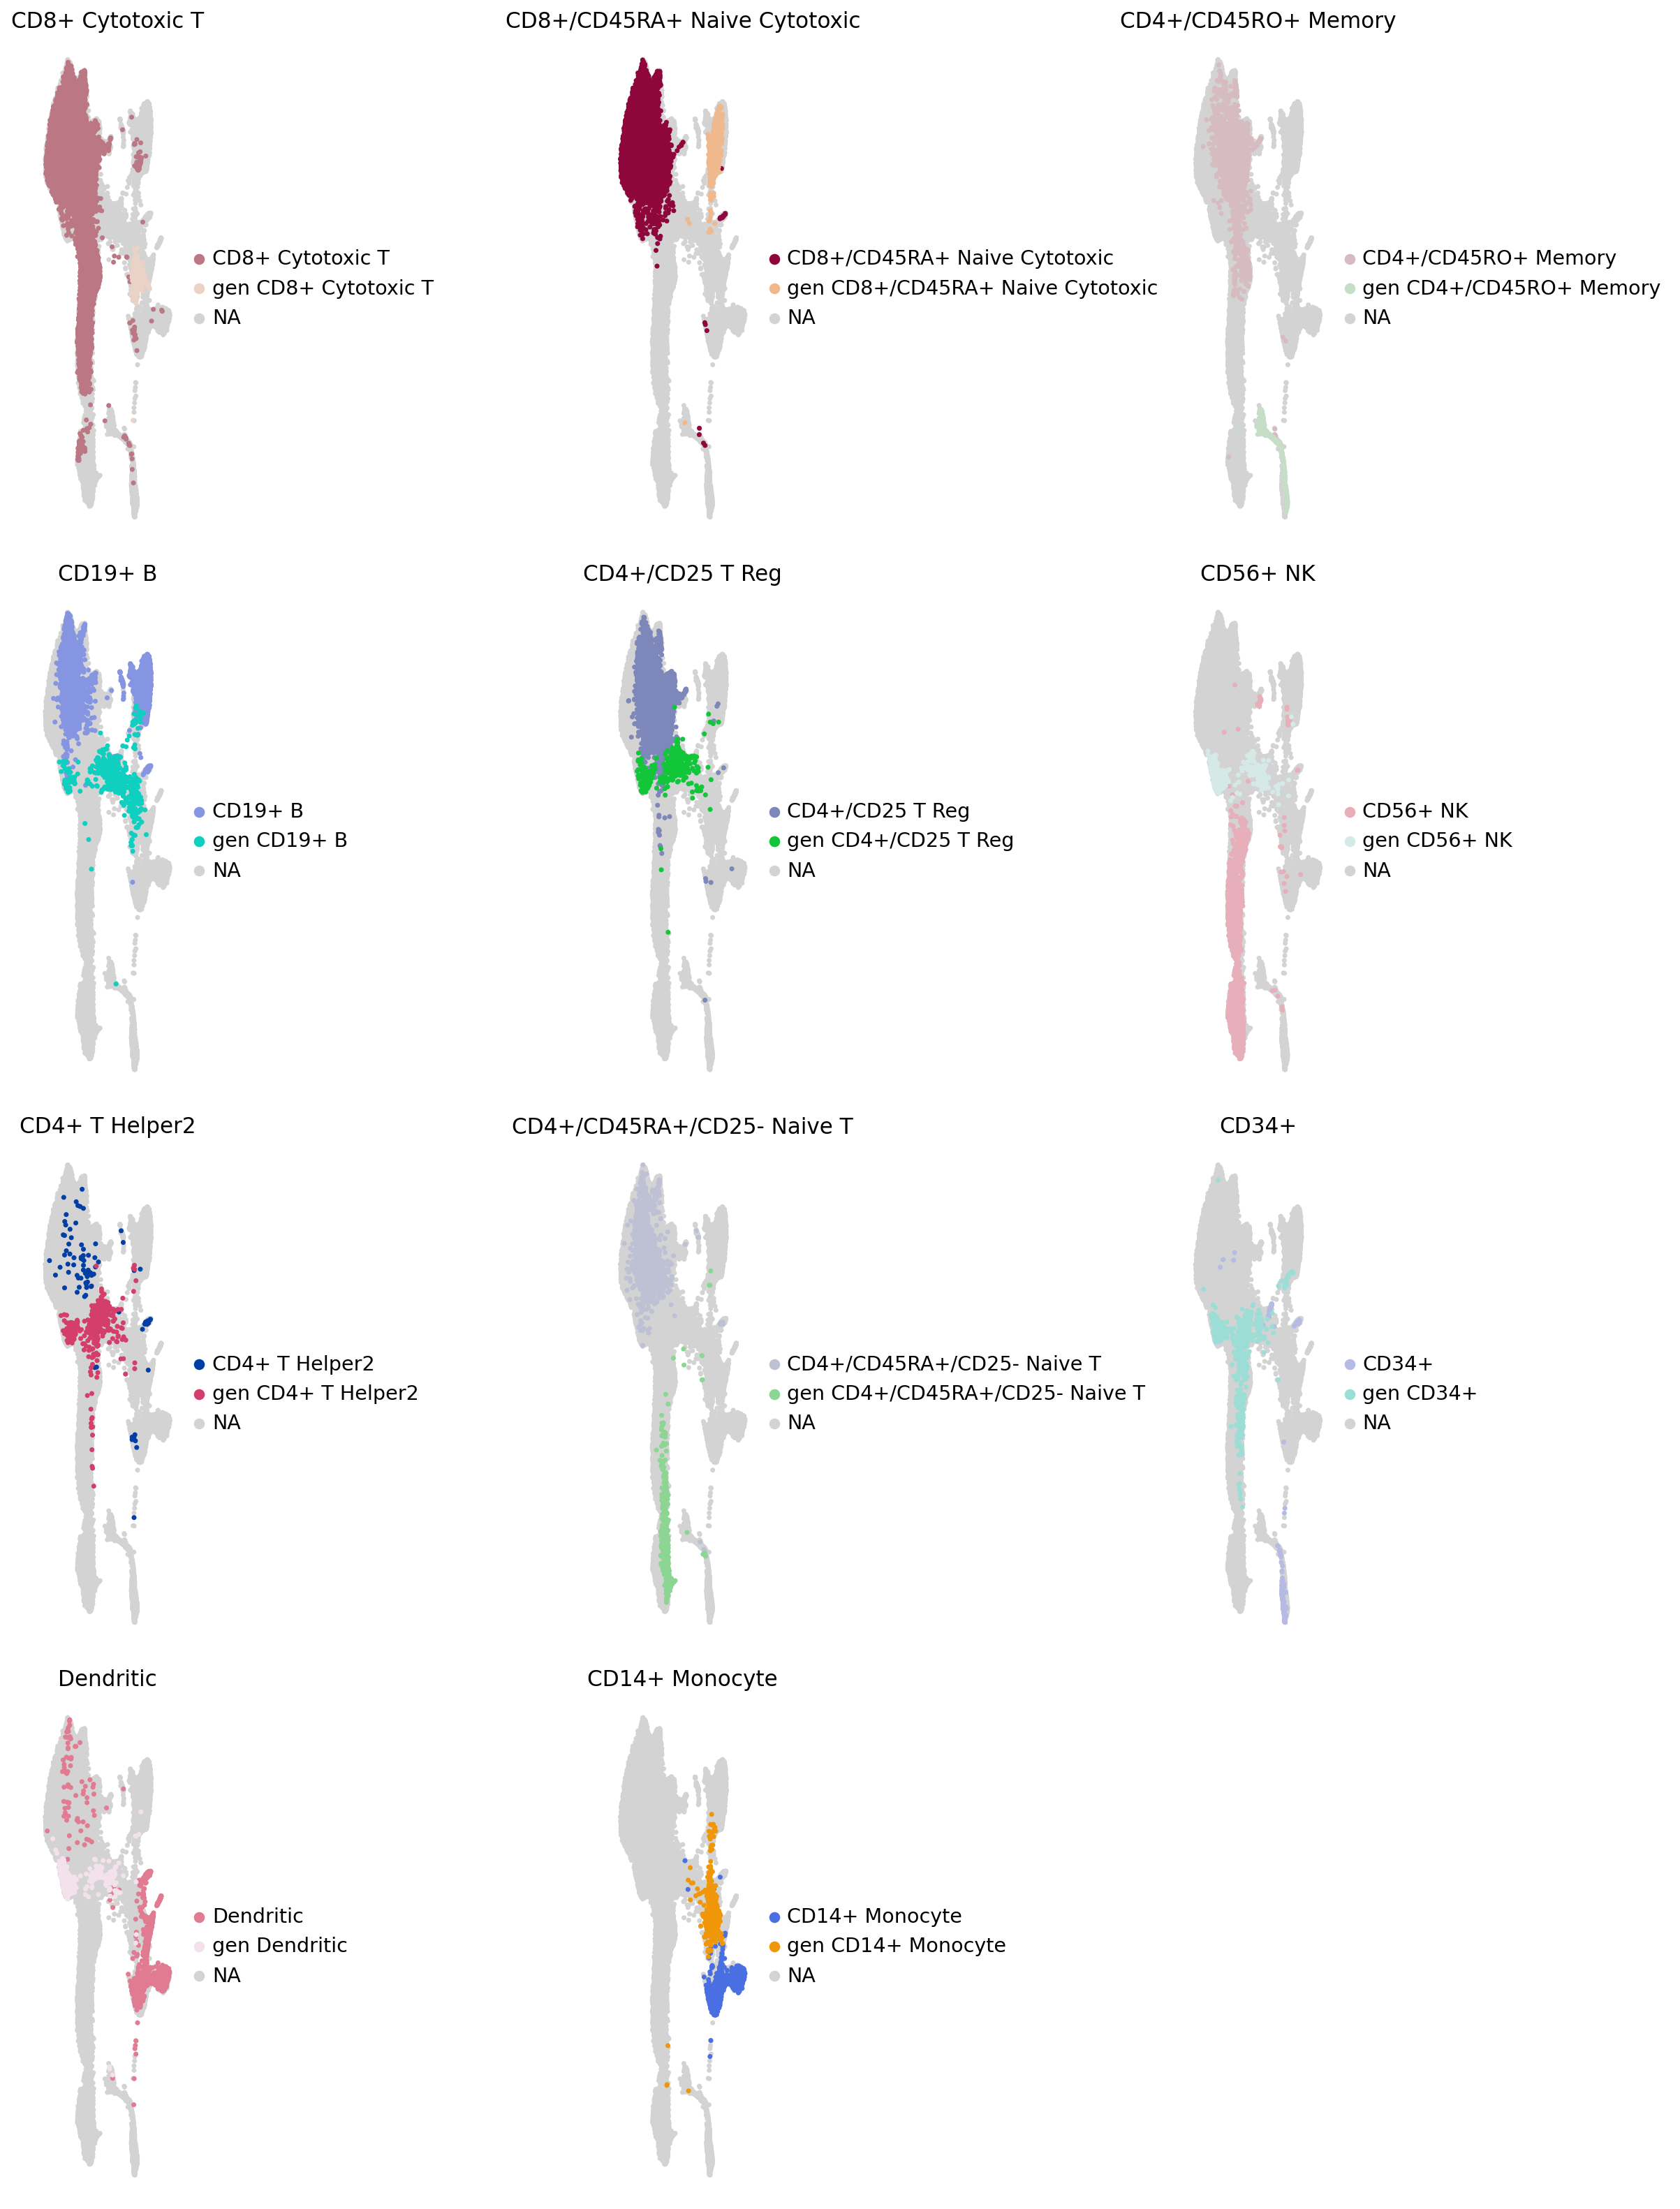

Individual plots created for 11 cell types


In [12]:
# Individual cell type comparisons for pancreas
if 'adata_combined' in locals() and 'celltype' in adata_combined.obs.columns and cell_gen_conditional is not None:
    print("Creating individual cell type comparisons...")
    
    # Get unique cell types from real data
    real_cell_types = [ct for ct in adata_combined.obs['celltype'].unique() if not ct.startswith('gen ')]
    
    # Create subplots
    n_types = len(real_cell_types)
    n_cols = 3
    n_rows = (n_types + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, cell_type in enumerate(real_cell_types):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        # Plot this cell type
        groups_to_show = [cell_type]
        if f'gen {cell_type}' in adata_combined.obs['celltype'].unique():
            groups_to_show.append(f'gen {cell_type}')
        
        try:
            sc.pl.umap(adata_combined, color="celltype", groups=groups_to_show, 
                      size=40, ax=ax, show=False, frameon=False, title=f'{cell_type}')
        except Exception as e:
            print(f"Warning: Could not plot {cell_type}: {e}")
            ax.text(0.5, 0.5, f'No data for\n{cell_type}', ha='center', va='center', 
                   transform=ax.transAxes)
    
    # Hide empty subplots
    for i in range(n_types, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Individual plots created for {len(real_cell_types)} cell types")
else:
    print("Cell type information not available for individual comparisons")
    if 'adata_combined' in locals():
        print("Available obs columns:", list(adata_combined.obs.columns))

In [15]:
adata_combined.obs["celltype"].unique()

['CD8+ Cytotoxic T', 'CD8+/CD45RA+ Naive Cytotoxic', 'CD4+/CD45RO+ Memory', 'CD19+ B', 'CD4+/CD25 T Reg', ..., 'gen CD4+ T Helper2', 'gen CD4+/CD45RA+/CD25- Naive T', 'gen CD34+', 'gen Dendritic', 'gen CD14+ Monocyte']
Length: 22
Categories (22, object): ['CD4+ T Helper2', 'CD4+/CD25 T Reg', 'CD4+/CD45RA+/CD25- Naive T', 'CD4+/CD45RO+ Memory', ..., 'gen CD19+ B', 'gen CD34+', 'gen CD56+ NK', 'gen Dendritic']

In [ ]:
# Separate cells based on whether celltype starts with "gen"
gen_mask = adata_combined.obs["celltype"].str.startswith("gen")
non_gen_mask = ~gen_mask

print(f"Cells with 'gen' celltype: {gen_mask.sum()}")
print(f"Cells without 'gen' celltype: {non_gen_mask.sum()}")

# Create separate AnnData objects
adata_gen = adata_combined[gen_mask].copy()
adata_non_gen = adata_combined[non_gen_mask].copy()

print(f"Generated cells data shape: {adata_gen.shape}")
print(f"Real cells data shape: {adata_non_gen.shape}")

# Create UMAP plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# UMAP for generated cells (starting with "gen")
sc.pl.umap(adata_gen, 
           color='celltype', 
           ax=axes[0], 
           title='Generated Cells (celltype starting with "gen")', 
           frameon=False, 
           show=False)

# UMAP for real cells (not starting with "gen")
sc.pl.umap(adata_non_gen, 
           color='celltype', 
           ax=axes[1], 
           title='Real Cells (celltype not starting with "gen")', 
           frameon=False, 
           show=False)

plt.tight_layout()
plt.show()

# Create PCA plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA for generated cells (starting with "gen")
sc.pl.pca(adata_gen, 
          color='celltype', 
          ax=axes[0], 
          title='Generated Cells PCA (celltype starting with "gen")', 
          frameon=False, 
          show=False)

# PCA for real cells (not starting with "gen")
sc.pl.pca(adata_non_gen, 
          color='celltype', 
          ax=axes[1], 
          title='Real Cells PCA (celltype not starting with "gen")', 
          frameon=False, 
          show=False)

plt.tight_layout()
plt.show()

print("UMAP and PCA plots created for generated vs real cells!")

## Summary and Results

In [13]:
print("=== PANCREAS DATASET UMAP ANALYSIS SUMMARY ===")
print(f"Real data shape: {cell_data.shape}")
if cell_gen is not None:
    print(f"Unconditional generated data shape: {cell_gen.shape}")
if cell_gen_conditional is not None:
    print(f"Conditional generated data shape: {cell_gen_conditional.shape}")
    print(f"Generated cell types: {set([ct.replace('gen ', '') for ct in gen_class])}")

if celltype is not None:
    print(f"Real cell types: {list(celltype.unique())}")

if 'corr_coef' in locals():
    print(f"Unconditional correlation: {corr_coef:.4f}")
if 'corr_coef_cond' in locals():
    print(f"Conditional correlation: {corr_coef_cond:.4f}")

print("\nUMAP visualizations have been created showing:")
print("1. Real vs Generated cells comparison")
print("2. Cell type distribution")
if cell_gen_conditional is not None:
    print("3. Individual cell type comparisons")

print("\nAnalysis completed!")

=== PANCREAS DATASET UMAP ANALYSIS SUMMARY ===
Real data shape: (68579, 32738)
Conditional generated data shape: (5500, 32738)
Generated cell types: {'CD19+ B', 'CD8+ Cytotoxic T', 'CD4+/CD25 T Reg', 'CD4+/CD45RO+ Memory', 'CD34+', 'Dendritic', 'CD4+ T Helper2', 'CD14+ Monocyte', 'CD56+ NK', 'CD8+/CD45RA+ Naive Cytotoxic', 'CD4+/CD45RA+/CD25- Naive T'}
Real cell types: ['CD8+ Cytotoxic T', 'CD8+/CD45RA+ Naive Cytotoxic', 'CD4+/CD45RO+ Memory', 'CD19+ B', 'CD4+/CD25 T Reg', 'CD56+ NK', 'CD4+ T Helper2', 'CD4+/CD45RA+/CD25- Naive T', 'CD34+', 'Dendritic', 'CD14+ Monocyte']
Conditional correlation: 0.9958

UMAP visualizations have been created showing:
1. Real vs Generated cells comparison
2. Cell type distribution
3. Individual cell type comparisons

Analysis completed!
